# Customer Segmentation Analysis Using RFM & K-Means Clustering

# Project Overview
This project aims to segment customer based on their purchasing behaviour using RFM Analysis & K-Means Clustering

RFM stands for :
- Recency : How recently a customer made a purchase
- Frequency : How often a customer make purchases
- Monetary : How Much money a customer spends

the goals is to identify customer groups and provide business recommendaations for marketing and customer retention

# 1. Import Library

In [150]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings("ignore")

# 2. Load Dataset
the cleaned Superstore dataset is loaded for customer segmentation analysis 

In [152]:
df = pd.read_csv('Superstore_cleaned.csv')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Quantity,Discount,Profit,Year,Month,Month Name,Year Month,Shipping Duration,Profit Margin,Profit Status
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,2,0.00,41.9136,2016,11,November,2016-11,3,0.1600,Profit
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,3,0.00,219.5820,2016,11,November,2016-11,3,0.3000,Profit
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,2,0.00,6.8714,2016,6,June,2016-06,4,0.4700,Profit
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,5,0.45,-383.0310,2015,10,October,2015-10,7,-0.4000,Loss
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,2,0.20,2.5164,2015,10,October,2015-10,7,0.1125,Profit


# 3. Intial Data Check
This step checks the dataset shape, column information, and important customer-relation fields

In [154]:
print("Dataset Shape", df.shape)
df.info()

Dataset Shape (9994, 28)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 28 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Row ID             9994 non-null   int64  
 1   Order ID           9994 non-null   object 
 2   Order Date         9994 non-null   object 
 3   Ship Date          9994 non-null   object 
 4   Ship Mode          9994 non-null   object 
 5   Customer ID        9994 non-null   object 
 6   Customer Name      9994 non-null   object 
 7   Segment            9994 non-null   object 
 8   Country            9994 non-null   object 
 9   City               9994 non-null   object 
 10  State              9994 non-null   object 
 11  Postal Code        9994 non-null   int64  
 12  Region             9994 non-null   object 
 13  Product ID         9994 non-null   object 
 14  Category           9994 non-null   object 
 15  Sub-Category       9994 non-null   object 
 16 

In [155]:
df[[
    'Customer ID',
    'Customer Name',
    'Order ID',
    'Order Date',
    'Sales'
]].head()

,Customer ID,Customer Name,Order ID,Order Date,Sales
0,CG-12520,Claire Gute,CA-2016-152156,2016-11-08,261.9600
1,CG-12520,Claire Gute,CA-2016-152156,2016-11-08,731.9400
2,DV-13045,Darrin Van Huff,CA-2016-138688,2016-06-12,14.6200
3,SO-20335,Sean O'Donnell,US-2015-108966,2015-10-11,957.5775
4,SO-20335,Sean O'Donnell,US-2015-108966,2015-10-11,22.3680


# 4. Convert Date Column
The Order Date Column is converted into datetime format to calculate customer recency

In [157]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Order Date'].head()

0   2016-11-08
1   2016-11-08
2   2016-06-12
3   2015-10-11
4   2015-10-11
Name: Order Date, dtype: datetime64[ns]

# 5.Create SnapShot Date
A snapshot date is created using the latest order date plus one day. This date is used as the reference point to calculate Receny

In [159]:
snapshot_date = df['Order Date'].max() + pd.Timedelta(days=1)
snapshot_date

Timestamp('2017-12-31 00:00:00')

# RFM Anaysis
RFM Analysis is used to evaluate customer behavior based on:
- Recency : Days since the last purchase
- Frequency : Number of unique prders
- Monetary : Total Spending

In [161]:
rfm = df.groupby('Customer ID').agg({
    'Order Date' : lambda x:(snapshot_date -x.max()).days,
    'Order ID' : 'nunique',
    'Sales' : 'sum'
})

rfm.columns = ['Recency','Frequency','Monetary']
rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
AA-10315,185,5,5563.560
AA-10375,20,9,1056.390
AA-10480,260,4,1790.512
AA-10645,56,6,5086.935
AB-10015,416,3,886.156


# 6. RFM Summary Statistics
this step shows the distributions and range of Recency, Frequency, and Monetary values.

In [163]:
rfm.describe()

,Recency,Frequency,Monetary
count,793.000000,793.000000,793.000000
mean,147.802018,6.316520,2896.848500
std,186.211051,2.550885,2628.670117
min,1.000000,1.000000,4.833000
25%,31.000000,5.000000,1146.050000
50%,76.000000,6.000000,2256.394000
75%,184.000000,8.000000,3785.276000
max,1166.000000,17.000000,25043.050000


## 7. RFM Distribution

The distribution of Recency, Frequency, and Monetary is visualized to understand customer behavior patterns.

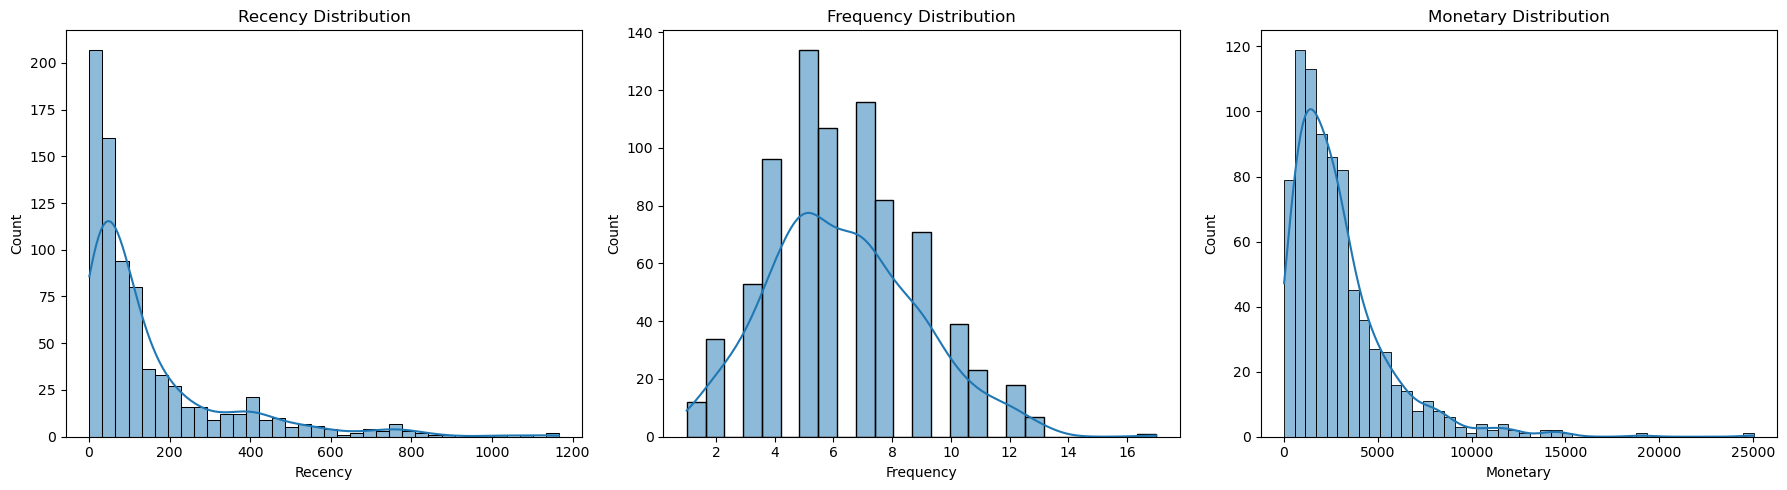

In [165]:
fig,axes = plt.subplots(1,3, figsize=(18,5))

sns.histplot(rfm['Recency'],kde=True, ax=axes[0])
axes[0].set_title('Recency Distribution')

sns.histplot(rfm['Frequency'], kde=True, ax=axes[1])
axes[1].set_title('Frequency Distribution')

sns.histplot(rfm['Monetary'],kde=True, ax=axes[2])
axes[2].set_title('Monetary Distribution')

plt.tight_layout()
plt.show()

# Feature Scaling

RFM variables have different scales.  
StandardScaler is used so that each variable contributes equally to the clustering process.

In [167]:
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm)

rfm_scaled = pd.DataFrame(
    rfm_scaled,
    columns=rfm.columns,
    index=rfm.index
)

rfm_scaled.head()

,Recency,Frequency,Monetary
Customer ID,,,
AA-10315,0.199889,-0.516429,1.015112
AA-10375,-0.686762,1.052644,-0.700590
AA-10480,0.602912,-0.908697,-0.421139
AA-10645,-0.493311,-0.124161,0.833680
AB-10015,1.441199,-1.300965,-0.765391


# Elbow Method

The Elbow Method is used to find the optimal number of clusters for K-Means.

In [169]:
inertia = []

for k in range (2,11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

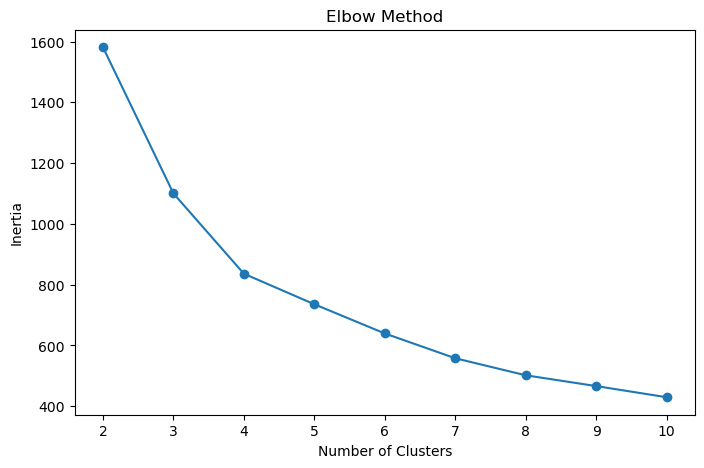

In [170]:
plt.figure(figsize=(8,5))
plt.plot(range(2,11), inertia, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

# Silhouette Score

Silhouette Score is used to evaluate how well the customers are grouped into clusters.  
A higher score indicates better cluster separation.

In [172]:
silhouette_scores = []

for k in range(2,11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(rfm_scaled)
    score = silhouette_score(rfm_scaled, labels)
    silhouette_scores.append(score)

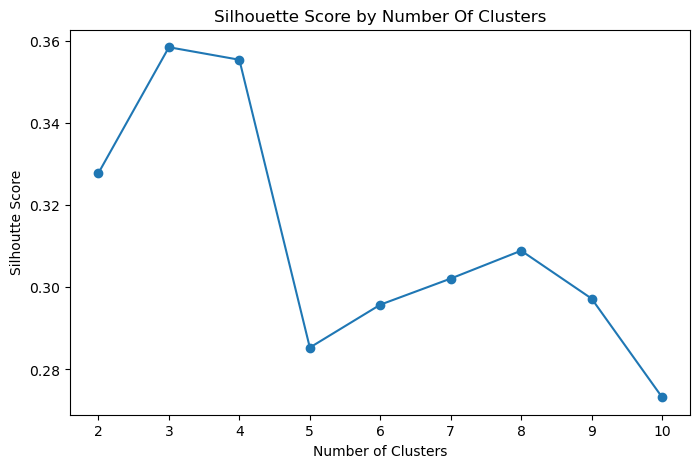

In [173]:
plt.figure(figsize=(8,5))
plt.plot(range(2,11), silhouette_scores, marker='o')
plt.title('Silhouette Score by Number Of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhoutte Score')

plt.show()

# K-Means Clustering

Based on the Elbow Method and Silhouette Score, K-Means clustering is applied to segment customers.

In this project, we use 4 clusters as the initial segmentation model.

In [175]:
kmeans = KMeans(
    n_clusters = 4,
    random_state = 42,
    n_init = 10
)

rfm['Clusters'] = kmeans.fit_predict(rfm_scaled)
rfm_scaled.head()

,Recency,Frequency,Monetary
Customer ID,,,
AA-10315,0.199889,-0.516429,1.015112
AA-10375,-0.686762,1.052644,-0.700590
AA-10480,0.602912,-0.908697,-0.421139
AA-10645,-0.493311,-0.124161,0.833680
AB-10015,1.441199,-1.300965,-0.765391


## 8. Cluster Distribution

This step shows how many customers belong to each cluster.

In [177]:
rfm['Clusters'].value_counts().sort_index()

Clusters
0    298
1    335
2     64
3     96
Name: count, dtype: int64

## 9. Cluster Profile

The average Recency, Frequency, and Monetary values are calculated for each cluster to understand customer characteristics.

In [179]:
cluster_profile = rfm.groupby('Clusters').agg({
    'Recency' : 'mean',
    'Frequency' : 'mean',
    'Monetary' : 'mean'
}).round(2)

cluster_profile

,Recency,Frequency,Monetary
Clusters,,,
0,72.74,8.52,3322.22
1,101.20,4.73,1669.69
2,123.72,8.30,9479.55
3,559.49,3.70,1470.23


## 10. Cluster Visualization

This scatter plot shows customer groups based on Frequency and Monetary value.

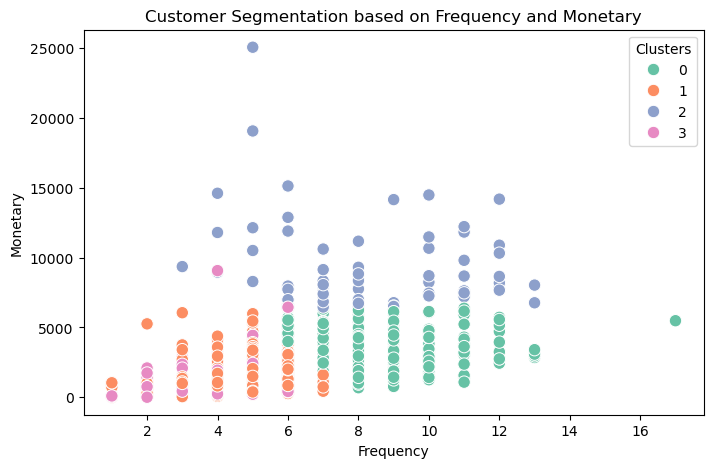

In [181]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=rfm,
    x='Frequency',
    y='Monetary',
    hue='Clusters',
    palette='Set2',
    s=80
)

plt.title('Customer Segmentation based on Frequency and Monetary')
plt.xlabel('Frequency')
plt.ylabel('Monetary')
plt.show()

# Customer Segment Naming

Each cluster is assigned a business-friendly segment name based on its Recency, Frequency, and Monetary characteristics.

In [183]:
cluster_profile

,Recency,Frequency,Monetary
Clusters,,,
0,72.74,8.52,3322.22
1,101.20,4.73,1669.69
2,123.72,8.30,9479.55
3,559.49,3.70,1470.23


## 11. Assign Segment Names

The segment names below can be adjusted based on the cluster profile results.

In [185]:
segment_map = {
    0: 'Loyal Customer',
    1: 'Potential Customer',
    2: 'Champions',
    3: 'At Risk Customer'
}
rfm['Segment'] = rfm['Clusters'].map(segment_map)
rfm.head()

,Recency,Frequency,Monetary,Clusters,Segment
Customer ID,,,,,
AA-10315,185,5,5563.560,1,Potential Customer
AA-10375,20,9,1056.390,0,Loyal Customer
AA-10480,260,4,1790.512,1,Potential Customer
AA-10645,56,6,5086.935,0,Loyal Customer
AB-10015,416,3,886.156,3,At Risk Customer


## 12. Segment Distribution

This step shows the number of customers in each segment.

In [187]:
segment_distribution = rfm['Segment'].value_counts()
segment_distribution

Segment
Potential Customer    335
Loyal Customer        298
At Risk Customer       96
Champions              64
Name: count, dtype: int64

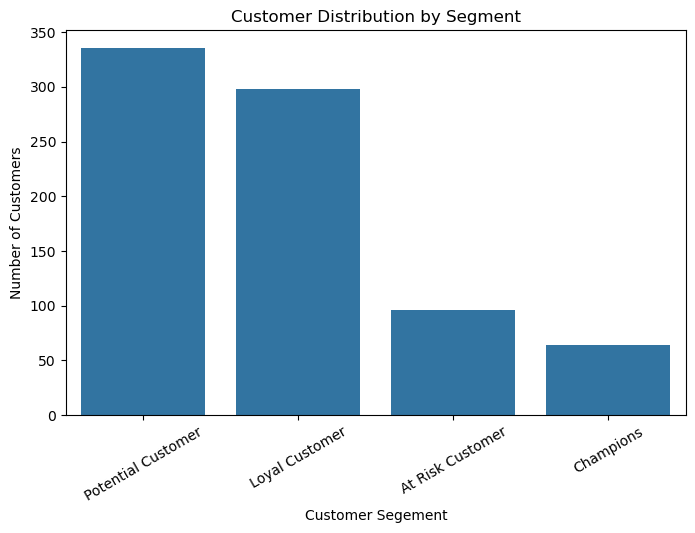

In [188]:
plt.figure(figsize=(8,5))
sns.barplot(
    x=segment_distribution.index,
    y=segment_distribution.values
)

plt.title('Customer Distribution by Segment')
plt.xlabel('Customer Segement')
plt.ylabel('Number of Customers')
plt.xticks(rotation=30)
plt.show()

## 13. Revenue Contribution by Segment

This analysis shows how much revenue is generated by each customer segment.

In [190]:
segment_revenue = rfm.groupby('Segment')['Monetary'].sum().sort_values(ascending=False)
segment_revenue

Segment
Loyal Customer        990022.4494
Champions             606690.9240
Potential Customer    559345.5772
At Risk Customer      141141.9097
Name: Monetary, dtype: float64

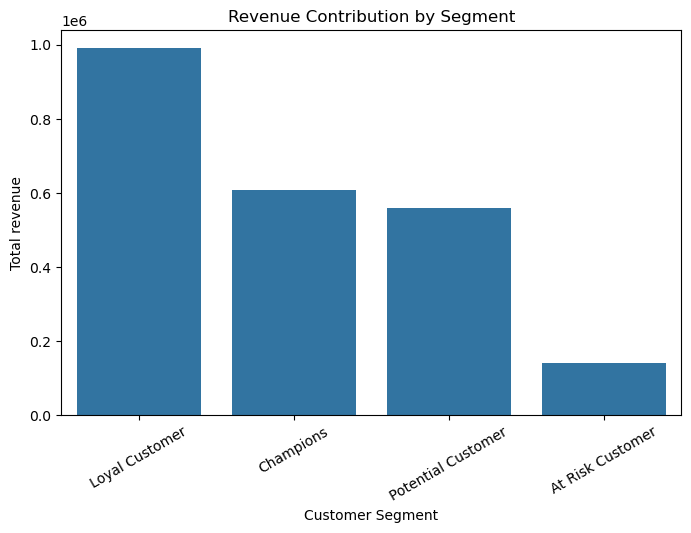

In [191]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=segment_revenue.index,
    y=segment_revenue.values
)
plt.title('Revenue Contribution by Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Total revenue')
plt.xticks(rotation=30)
plt.show()

## 14. Average RFM by Segment

This step compares the average Recency, Frequency, and Monetary values for each customer segment.

In [193]:
segment_profile = rfm.groupby('Segment').agg({
    'Recency' : 'mean',
    'Frequency' : 'mean',
    'Monetary' : 'mean'
}).round(2)

segment_profile

,Recency,Frequency,Monetary
Segment,,,
At Risk Customer,559.49,3.70,1470.23
Champions,123.72,8.30,9479.55
Loyal Customer,72.74,8.52,3322.22
Potential Customer,101.20,4.73,1669.69


## 15. Merge Customer Information

Customer names are added back to the RFM table to make the result easier to interpret and export for Tableau.

In [195]:
customer_info = df[[
    "Customer ID",
    "Customer Name",
    "Region"
]].drop_duplicates("Customer ID")

customer_segmentation = rfm.reset_index().merge(
    customer_info,
    on="Customer ID",
    how="left"
)

customer_segmentation.head()

,Customer ID,Recency,Frequency,Monetary,Clusters,Segment,Customer Name,Region
0,AA-10315,185,5,5563.560,1,Potential Customer,Alex Avila,Central
1,AA-10375,20,9,1056.390,0,Loyal Customer,Allen Armold,West
2,AA-10480,260,4,1790.512,1,Potential Customer,Andrew Allen,South
3,AA-10645,56,6,5086.935,0,Loyal Customer,Anna Andreadi,East
4,AB-10015,416,3,886.156,3,At Risk Customer,Aaron Bergman,West


## 16. Export Dataset for Tableau

The final customer segmentation dataset is exported to CSV for dashboard creation in Tableau.

In [197]:
customer_segmentation.to_csv(
    'customer_segmentation.csv',
    index=False
)

In [198]:
summary = customer_segmentation.groupby('Segment').agg({
    'Customer ID': 'count',
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean'
}).round(2)

summary.columns = [
    'Total Customers',
    'Average Recency',
    'Average Frequency',
    'Average Monetary'
]

summary

,Total Customers,Average Recency,Average Frequency,Average Monetary
Segment,,,,
At Risk Customer,96,559.49,3.70,1470.23
Champions,64,123.72,8.30,9479.55
Loyal Customer,298,72.74,8.52,3322.22
Potential Customer,335,101.20,4.73,1669.69
